# 03 – N-body simulation and snapshots

In this notebook we run a small N-body simulation starting from Gaussian
initial conditions, using the public `fwd_model_tools` API.

The main steps are:

1. Draw Gaussian initial conditions on a 3D mesh.
2. Compute LPT displacements and momenta at an initial scale factor.
3. Run an N-body evolution to a few snapshot times.
4. Paint the resulting snapshots into flat-sky and spherical density maps.


## Imports & configuration
We configure JAX to run on CPU, import the public `fwd_model_tools` API,
and set up a moderate mesh/box size so the notebook executes comfortably
on a laptop.


In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax_cosmo as jc

from fwd_model_tools import (
    FieldStatus,
    DensityField,
    FlatDensity,
    SphericalDensity,
    gaussian_initial_conditions,
    lpt,
    nbody,
    compute_snapshot_scale_factors,
    Planck18,
)

# Simulation parameters
mesh_size = (128, 128, 128)
box_size = (1000.0, 1000.0, 1000.0)  # Mpc/h
observer_position = (0.5, 0.5, 0.5)
nside = 64
flatsky_npix = (128, 128)

# N-body parameters
t0 = 0.1   # Initial scale factor
t1 = 1.0   # Final scale factor
dt0 = 0.05 # Time step
nb_shells = 3

# Random seed and cosmology
key = jax.random.PRNGKey(42)
cosmo = Planck18()

print("Mesh size:", mesh_size)
print("Box size:", box_size, "Mpc/h")


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
ERROR:2025-11-19 15:49:05,784:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cud

Mesh size: (128, 128, 128)
Box size: (1000.0, 1000.0, 1000.0) Mpc/h


## Gaussian initial conditions
We draw Gaussian initial conditions on the 3D mesh, attaching both
flat-sky (`flatsky_npix`) and spherical (`nside`) metadata so we can
paint snapshots to either geometry later.


In [2]:
gaussian_field = gaussian_initial_conditions(
    key=key,
    mesh_size=mesh_size,
    box_size=box_size,
    cosmo=cosmo,
    observer_position=observer_position,
    nside=nside,
    flatsky_npix=flatsky_npix,
)

print("Initial field:", gaussian_field)
print("Status:", gaussian_field.status)
print("Array shape:", gaussian_field.array.shape)


Initial field: DensityField(array=Array(128, 128, 128), mesh_size=(128, 128, 128), box_size=(1000.0, 1000.0, 1000.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD
Array shape: (128, 128, 128)


## LPT initial conditions at $a = t_0$
We compute first-order LPT displacements and momenta at the initial
scale factor `t0`. These serve as starting conditions for the N-body
integrator.


In [3]:
dx_field, p_field = lpt(cosmo, gaussian_field, a=t0, order=1)

print("Displacement field:", dx_field)
print("  Status:", dx_field.status)
print("  Array shape:", dx_field.array.shape)
print("  Scale factors:", dx_field.scale_factors)
print("Max comoving radius:", dx_field.max_comoving_radius)


shape of initial force: (128, 128, 128, 3)
growth factor shape: (1,)
Displacement field: ParticleField(array=Array(128, 128, 128, 3), mesh_size=(128, 128, 128), box_size=(1000.0, 1000.0, 1000.0), status=lpt1, scale_factors_shape=(1,))
  Status: FieldStatus.LPT1
  Array shape: (128, 128, 128, 3)
  Scale factors: [0.1]
Max comoving radius: 500.0


## Snapshot times and comoving centers
We choose a small number of snapshot scale factors using
`compute_snapshot_scale_factors` and convert them to comoving distances.
These comoving radii will be used as painting centers for the snapshots.


In [4]:
ts = compute_snapshot_scale_factors(cosmo, gaussian_field, nb_shells=nb_shells)
r_centers = jc.background.radial_comoving_distance(cosmo, ts)

print("Snapshot scale factors (ts):", ts)
print("Comoving centers r(ts) [Mpc/h]:", r_centers)


Snapshot scale factors (ts): [0.87417812 0.92158208 0.97277129]
Comoving centers r(ts) [Mpc/h]: [416.78449694 250.          83.39757401]


## Run N-body with particle geometry
We now evolve the system from `t0` to `t1`, saving particle snapshots at
the selected scale factors `ts`. The `geometry='particles'` mode returns
stacked `ParticleField` objects with one entry per snapshot.


In [5]:
density_snapshots = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    ts=ts,
    geometry="particles",
)

print("Snapshots ParticleField:", density_snapshots)
print("Array shape:", density_snapshots.array.shape)
print("Snapshot scale_factors on field:", density_snapshots.scale_factors)

structure of dx_field = PyTreeDef(CustomNode(ParticleField[((128, 128, 128), (1000.0, 1000.0, 1000.0), (0.5, 0.5, 0.5), None, 64, (128, 128), None, (0, 0), None, <FieldStatus.LPT1: 'lpt1'>)], [*, *]))
structure of p_field = PyTreeDef(CustomNode(ParticleField[((128, 128, 128), (1000.0, 1000.0, 1000.0), (0.5, 0.5, 0.5), None, 64, (128, 128), None, (0, 0), None, <FieldStatus.LPT1: 'lpt1'>)], [*, *]))
Snapshots ParticleField: ParticleField(array=Array(3, 128, 128, 128, 3), mesh_size=(128, 128, 128), box_size=(1000.0, 1000.0, 1000.0), status=lpt1, scale_factors_shape=(3,))
Array shape: (3, 128, 128, 128, 3)
Snapshot scale_factors on field: [0.97277129 0.92158208 0.87417812]


## Flat-sky projections of snapshots
We paint each snapshot into a flat-sky density map using the comoving
centers `r_centers` and visualize the resulting stack.


FlatDensity stack: FlatDensity(array=Array(3, 128, 128), mesh_size=(128, 128, 128), box_size=(1000.0, 1000.0, 1000.0), status=lightcone, scale_factors_shape=(3,))
FlatDensity array shape: (3, 128, 128)


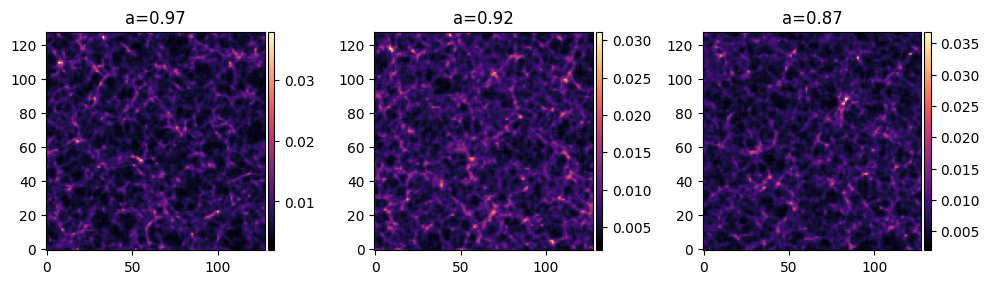

In [ ]:
flat_densities = density_snapshots.paint_2d(center=r_centers)
print("FlatDensity stack:", flat_densities)
print("FlatDensity array shape:", flat_densities.array.shape)  # (n_snap, ny, nx)

flat_titles = [f"a={a:.2f}" for a in density_snapshots.scale_factors]
flat_densities.show(titles=flat_titles, figsize=(10, 4))


## Spherical projections of snapshots
For the same snapshots we can also paint onto a HEALPix sphere. This is a
true N-body lightcone (unlike the LPT-only lightcone in Notebook 02), so
spherical painting is supported here.


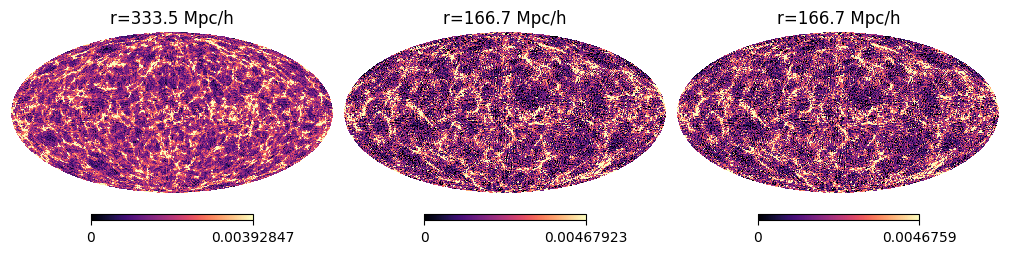

In [7]:
snapshots_spherical = density_snapshots.replace(nside=nside)

# Use density shell width inferred from max radius
density_width = snapshots_spherical.density_width(nb_shells=nb_shells)
shifted_centers = r_centers - density_width / 2
shifted_centers = shifted_centers.at[-1].add(density_width)

spherical_densities = snapshots_spherical.paint_spherical(
    center=shifted_centers,
    scheme="ngp",
    batch_size=nb_shells,
    paint_nside=256,
)

sph_titles = [f"r={r:.1f} Mpc/h" for r in shifted_centers]
spherical_densities.show(titles=sph_titles, figsize=(10, 4), apply_log=False)


## Summary

In this notebook we:
- sampled Gaussian initial conditions on a 3D mesh,
- computed first-order LPT displacements and momenta at an initial scale factor,
- evolved the system with an N-body integrator to a few snapshot times,
- painted the resulting snapshots into flat-sky and spherical density maps.

These N-body snapshots and their projections provide the building blocks for
forward-modeling pipelines that compare to observations in different geometries.
